In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_dir = "../data"

print("Files in ../data:")
for f in os.listdir(data_dir):
    print(f)

Files in ../data:
.ipynb_checkpoints
beam_map_331F1_pol1.grd
beam_map_331F1_pol1_brad.grd


In [ ]:
50 min / 62 tasks vs x min / 2648 tasks

In [ ]:
~2135 minutes 

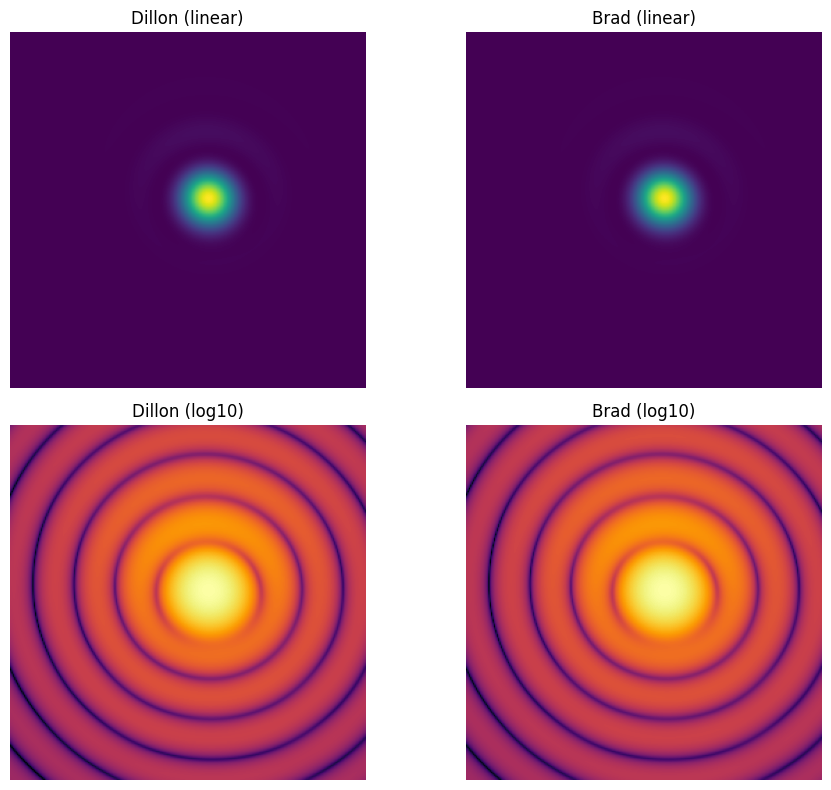

In [4]:
# filenames
file_you = "beam_map_331F1_pol1.grd"
file_brad = "beam_map_331F1_pol1_brad.grd"

def load_grd(filepath):
    with open(filepath, "r") as f:
        lines = f.readlines()

    # find grid size line
    for i, line in enumerate(lines):
        parts = line.split()
        if len(parts) == 3:
            try:
                nx, ny, nz = map(int, parts)
                if nz == 0:
                    grid_line = i
                    break
            except:
                pass

    # read data
    rows = []
    for line in lines[grid_line + 1:]:
        parts = line.split()
        if len(parts) == 4:
            rows.append([float(x) for x in parts])

    arr = np.array(rows)

    # build complex fields
    E1 = arr[:,0] + 1j * arr[:,1]
    E2 = arr[:,2] + 1j * arr[:,3]

    power = np.abs(E1)**2 + np.abs(E2)**2
    img = power.reshape(ny, nx)

    return img


# load both
img_you = load_grd("../data/" + file_you)
img_brad = load_grd("../data/" + file_brad)

# normalize both (important for fair comparison)
img_you /= np.max(img_you)
img_brad /= np.max(img_brad)

# log versions
img_you_log = np.log10(img_you + 1e-12)
img_brad_log = np.log10(img_brad + 1e-12)

# ===== plot =====
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# linear
axs[0,0].imshow(img_you, origin="lower")
axs[0,0].set_title("Dillon (linear)")

axs[0,1].imshow(img_brad, origin="lower")
axs[0,1].set_title("Brad (linear)")

# log
axs[1,0].imshow(img_you_log, origin="lower", cmap="inferno")
axs[1,0].set_title("Dillon (log10)")

axs[1,1].imshow(img_brad_log, origin="lower", cmap="inferno")
axs[1,1].set_title("Brad (log10)")

for ax in axs.flatten():
    ax.axis("off")

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

# difference
diff = img_you - img_brad

# basic stats
max_abs_diff = np.max(np.abs(diff))
mean_abs_diff = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))

# relative stats (avoid divide-by-zero)
eps = 1e-12
rel_diff = np.abs(diff) / (img_brad + eps)

max_rel_diff = np.max(rel_diff)
mean_rel_diff = np.mean(rel_diff)

# correlation (flattened)
corr = np.corrcoef(img_you.flatten(), img_brad.flatten())[0,1]

# peak comparison
peak_you = np.max(img_you)
peak_brad = np.max(img_brad)

# build table
stats = pd.DataFrame({
    "Metric": [
        "Max Abs Diff",
        "Mean Abs Diff",
        "RMSE",
        "Max Rel Diff",
        "Mean Rel Diff",
        "Correlation",
        "Peak (Me)",
        "Peak (Brad)"
    ],
    "Value": [
        max_abs_diff,
        mean_abs_diff,
        rmse,
        max_rel_diff,
        mean_rel_diff,
        corr,
        peak_you,
        peak_brad
    ]
})

stats

,Metric,Value
0,Max Abs Diff,0.000347
1,Mean Abs Diff,0.000009
2,RMSE,0.000034
3,Max Rel Diff,0.870323
4,Mean Rel Diff,0.008102
5,Correlation,1.000000
6,Peak (Me),1.000000
7,Peak (Brad),1.000000
